# Projet 2 : Chatbot Covid-19

**Objectif** : réaliser un Chatbot sous forme d'interrogatoire médical aidant les médecins à prendre des décisions plus vite que le temps ordinaire.

Ces données aideront à identifier si une personne est atteinte d'une maladie à coronavirus ou non en fonction de certains symptômes standards prédéfinis,
basés sur les directives de l'OMS et du ministère indien de la Santé.

> Avis de non-responsabilité : les résultats ou l'analyse de ces données ne doivent **pas** être considérés comme des conseils médicaux.

**Variables principales (7)** :
- Pays, Âge, Genre
- Symptômes principaux : fièvre, fatigue, toux sèche, difficulté à respirer, mal de gorge
- Symptômes secondaires : douleurs, congestion nasale, écoulement nasal, diarrhée
- Gravité (None / Mild / Moderate / Severe)
- Contact avec patient COVID

**Données** :
- `Raw-Data.csv` : registre des étiquettes possibles
- `Cleaned-Data.csv` : 316 800 combinaisons générées (créé en Section 2)

**Tâches** : (1) classification supervisée  (2) clustering non supervisé

Source : https://www.kaggle.com/iamhungundji/covid19-symptoms-checker


## Section 0 — Imports et configuration

In [1]:
import itertools
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, roc_curve)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')


Imports OK


## Section 1 — Extraction du vocabulaire depuis `Raw-Data.csv`

Le fichier `Raw-Data.csv` n'est **pas** un dataset relationnel : chaque colonne liste verticalement les valeurs possibles d'une variable. Les colonnes `Symptoms` et `Experiencing_Symptoms` contiennent par contre des **chaînes multi-valeurs** (ex: `"Fever,Tiredness,Dry-Cough"`).

Nous extrayons donc :
- pour les colonnes simples : la liste des valeurs uniques non nulles
- pour les colonnes multi-valeurs : la liste des chaînes brutes (pour reproduire les 316 800 combinaisons) **et** la liste des tokens atomiques (pour l'encodage multi-hot ultérieur)


In [2]:
raw = pd.read_csv('data/Raw-Data.csv')
print('Shape :', raw.shape)
raw.head(10)


Shape : (16, 7)


,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes
1,Italy,10-19,Female,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breathing","Pains,Nasal-Congestion,Runny-Nose",Moderate,No
2,Iran,20-24,Transgender,"Fever,Tiredness,Dry-Cough","Pains,Nasal-Congestion",Severe,Dont-Know
3,Republic of Korean,25-59,NaN,"Fever,Tiredness",Pains,NaN,NaN
4,France,60+,NaN,Fever,"Nasal-Congestion,Runny-Nose,Diarrhea",NaN,NaN
5,Spain,NaN,NaN,"Tiredness,Dry-Cough,Difficulty-in-Breathing,So...","Nasal-Congestion,Runny-Nose",NaN,NaN
6,Germany,NaN,NaN,"Tiredness,Dry-Cough,Difficulty-in-Breathing",Nasal-Congestion,NaN,NaN
7,UAE,NaN,NaN,"Tiredness,Dry-Cough","Runny-Nose,Diarrhea",NaN,NaN
8,Other-EUR,NaN,NaN,Tiredness,Runny-Nose,NaN,NaN
9,Other,NaN,NaN,"Dry-Cough,Difficulty-in-Breathing,Sore-Throat",Diarrhea,NaN,NaN


In [3]:
# Vocabulaire des variables simples (1 valeur par cellule)
SIMPLE_COLS = ['Country', 'Age', 'Gender', 'Severity', 'Contact']
vocab = {col: raw[col].dropna().unique().tolist() for col in SIMPLE_COLS}

# Severity dans Raw-Data ne contient que Mild/Moderate/Severe.
# La specification du projet mentionne aussi un niveau 'absence de gravite'.
# On l'ajoute explicitement comme 'Asymptomatic' pour atteindre 316 800 combinaisons.
# (On evite la chaine 'None' qui serait interpretee comme NaN par pandas a la relecture.)
if 'Asymptomatic' not in vocab['Severity']:
    vocab['Severity'].append('Asymptomatic')

for col, vals in vocab.items():
    print(f'{col:12s} ({len(vals)}) : {vals}')


Country      (10) : ['China', 'Italy', 'Iran', 'Republic of Korean', 'France', 'Spain', 'Germany', 'UAE', 'Other-EUR', 'Other']
Age          (5) : ['0-9', '10-19', '20-24', '25-59', '60+']
Gender       (3) : ['Male', 'Female', 'Transgender']
Severity     (4) : ['Mild', 'Moderate', 'Severe', 'Asymptomatic']
Contact      (3) : ['Yes', 'No', 'Dont-Know']


In [4]:
# Variables multi-valuees : on conserve les chaines brutes pour la generation
symptoms_strings = raw['Symptoms'].dropna().tolist()
experiencing_strings = raw['Experiencing_Symptoms'].dropna().tolist()

# Tokens atomiques (pour l'encodage multi-hot ulterieur)
def collect_tokens(strings):
    tokens = set()
    for s in strings:
        for t in s.split(','):
            tokens.add(t.strip())
    return sorted(tokens)

symptom_tokens = collect_tokens(symptoms_strings)
experiencing_tokens = collect_tokens(experiencing_strings)

print(f'Symptoms      : {len(symptoms_strings)} chaines, {len(symptom_tokens)} tokens uniques')
print(f'  Tokens      : {symptom_tokens}')
print(f'Experiencing  : {len(experiencing_strings)} chaines, {len(experiencing_tokens)} tokens uniques')
print(f'  Tokens      : {experiencing_tokens}')


Symptoms      : 16 chaines, 6 tokens uniques
  Tokens      : ['Difficulty-in-Breathing', 'Dry-Cough', 'Fever', 'None_Sympton', 'Sore-Throat', 'Tiredness']
Experiencing  : 11 chaines, 5 tokens uniques
  Tokens      : ['Diarrhea', 'Nasal-Congestion', 'None_Experiencing', 'Pains', 'Runny-Nose']


In [5]:
# Verification du compte attendu : 10 x 5 x 3 x 16 x 11 x 4 x 3 = 316 800
expected = (len(vocab['Country']) * len(vocab['Age']) * len(vocab['Gender'])
            * len(symptoms_strings) * len(experiencing_strings)
            * len(vocab['Severity']) * len(vocab['Contact']))
print(f'Nombre de combinaisons attendu : {expected:,}')
assert expected == 316_800, f'Compte invalide : {expected}'
print('Vocabulaire valide.')


Nombre de combinaisons attendu : 316,800
Vocabulaire valide.


## Section 2 — Génération de `Cleaned-Data.csv` (316 800 lignes)

### 2.1 Produit cartésien

On combine toutes les valeurs avec `itertools.product` pour obtenir 316 800 lignes.

### 2.2 Assignation du label `COVID_19`

Aucune ground truth n'est fournie. On utilise une **règle heuristique à base de score clinique** qui s'inspire des directives OMS :

| Facteur | Pondération |
|---------|-------------|
| Difficulty-in-Breathing | +2.0 |
| Fever | +1.5 |
| Dry-Cough | +1.5 |
| Tiredness | +1.0 |
| Sore-Throat | +0.5 |
| Chaque symptôme secondaire | +0.5 |
| Severity (None/Mild/Moderate/Severe) | 0 / 0.5 / 1.0 / 2.0 |
| Age 60+ | +1.0 |
| Contact = Yes | ×1.5 (multiplicateur) |
| Contact = Dont-Know | ×1.1 |

Seuil de décision : `score >= 3.0` ⇒ COVID positif.


In [6]:
SYMPTOM_WEIGHTS = {
    'Fever': 1.5,
    'Tiredness': 1.0,
    'Dry-Cough': 1.5,
    'Difficulty-in-Breathing': 2.0,
    'Sore-Throat': 0.5,
}
EXPERIENCING_WEIGHT = 0.5
SEVERITY_BONUS = {'Asymptomatic': 0.0, 'Mild': 0.5, 'Moderate': 1.0, 'Severe': 2.0}
AGE_RISK = {'0-9': 0.2, '10-19': 0.1, '20-24': 0.2, '25-59': 0.3, '60+': 1.0}
CONTACT_MULT = {'Yes': 1.5, 'No': 1.0, 'Dont-Know': 1.1}
COVID_THRESHOLD = 4.5  # calibre pour obtenir ~40-50% de positifs


def assign_covid_label(row):
    score = 0.0
    syms = row['Symptoms']
    if 'None_Sympton' not in syms:
        for token, w in SYMPTOM_WEIGHTS.items():
            if token in syms:
                score += w

    exps = row['Experiencing_Symptoms']
    if 'None_Experiencing' not in exps:
        for token in ['Pains', 'Nasal-Congestion', 'Runny-Nose', 'Diarrhea']:
            if token in exps:
                score += EXPERIENCING_WEIGHT

    score *= CONTACT_MULT.get(row['Contact'], 1.0)
    score += SEVERITY_BONUS.get(row['Severity'], 0.0)
    score += AGE_RISK.get(row['Age'], 0.0)
    return 1 if score >= COVID_THRESHOLD else 0


In [7]:
# Generation du produit cartesien
combinations = list(itertools.product(
    vocab['Country'],
    vocab['Age'],
    vocab['Gender'],
    symptoms_strings,
    experiencing_strings,
    vocab['Severity'],
    vocab['Contact']
))

df = pd.DataFrame(combinations, columns=[
    'Country', 'Age', 'Gender', 'Symptoms',
    'Experiencing_Symptoms', 'Severity', 'Contact'
])
print(f'Dataset genere : {df.shape}')
assert df.shape[0] == 316_800
df.head()


Dataset genere : (316800, 7)


,Country,Age,Gender,Symptoms,Experiencing_Symptoms,Severity,Contact
0,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Yes
1,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,No
2,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Mild,Dont-Know
3,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,Yes
4,China,0-9,Male,"Fever,Tiredness,Dry-Cough,Difficulty-in-Breath...","Pains,Nasal-Congestion,Runny-Nose,Diarrhea",Moderate,No


In [8]:
# Assignation des labels
df['COVID_19'] = df.apply(assign_covid_label, axis=1)
df.to_csv('data/Cleaned-Data.csv', index=False)
print('data/Cleaned-Data.csv sauvegarde.')

distrib = df['COVID_19'].value_counts(normalize=True).rename(
    index={0: 'Negatif', 1: 'Positif'}
)
print('\nDistribution du label :')
print(distrib.to_string())


data/Cleaned-Data.csv sauvegarde.

Distribution du label :
COVID_19
Positif    0.673106
Negatif    0.326894


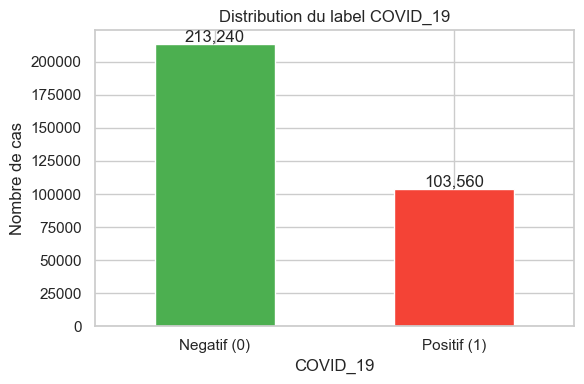

In [9]:
# Visualisation de la distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['COVID_19'].value_counts().plot(kind='bar', ax=ax, color=['#4caf50', '#f44336'])
ax.set_xticklabels(['Negatif (0)', 'Positif (1)'], rotation=0)
ax.set_title('Distribution du label COVID_19')
ax.set_ylabel('Nombre de cas')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


## Section 3 — Analyse Exploratoire des Données (EDA)


In [10]:
# Verifier l'integrite
assert os.path.exists('data/Cleaned-Data.csv'), 'data/Cleaned-Data.csv manquant'
df = pd.read_csv('data/Cleaned-Data.csv')

print('Shape :', df.shape)
print('\nDtypes :')
print(df.dtypes)
print('\nMissing values :')
print(df.isna().sum().to_string())


Shape : (316800, 8)

Dtypes :
Country                  object
Age                      object
Gender                   object
Symptoms                 object
Experiencing_Symptoms    object
Severity                 object
Contact                  object
COVID_19                  int64
dtype: object

Missing values :
Country                  0
Age                      0
Gender                   0
Symptoms                 0
Experiencing_Symptoms    0
Severity                 0
Contact                  0
COVID_19                 0


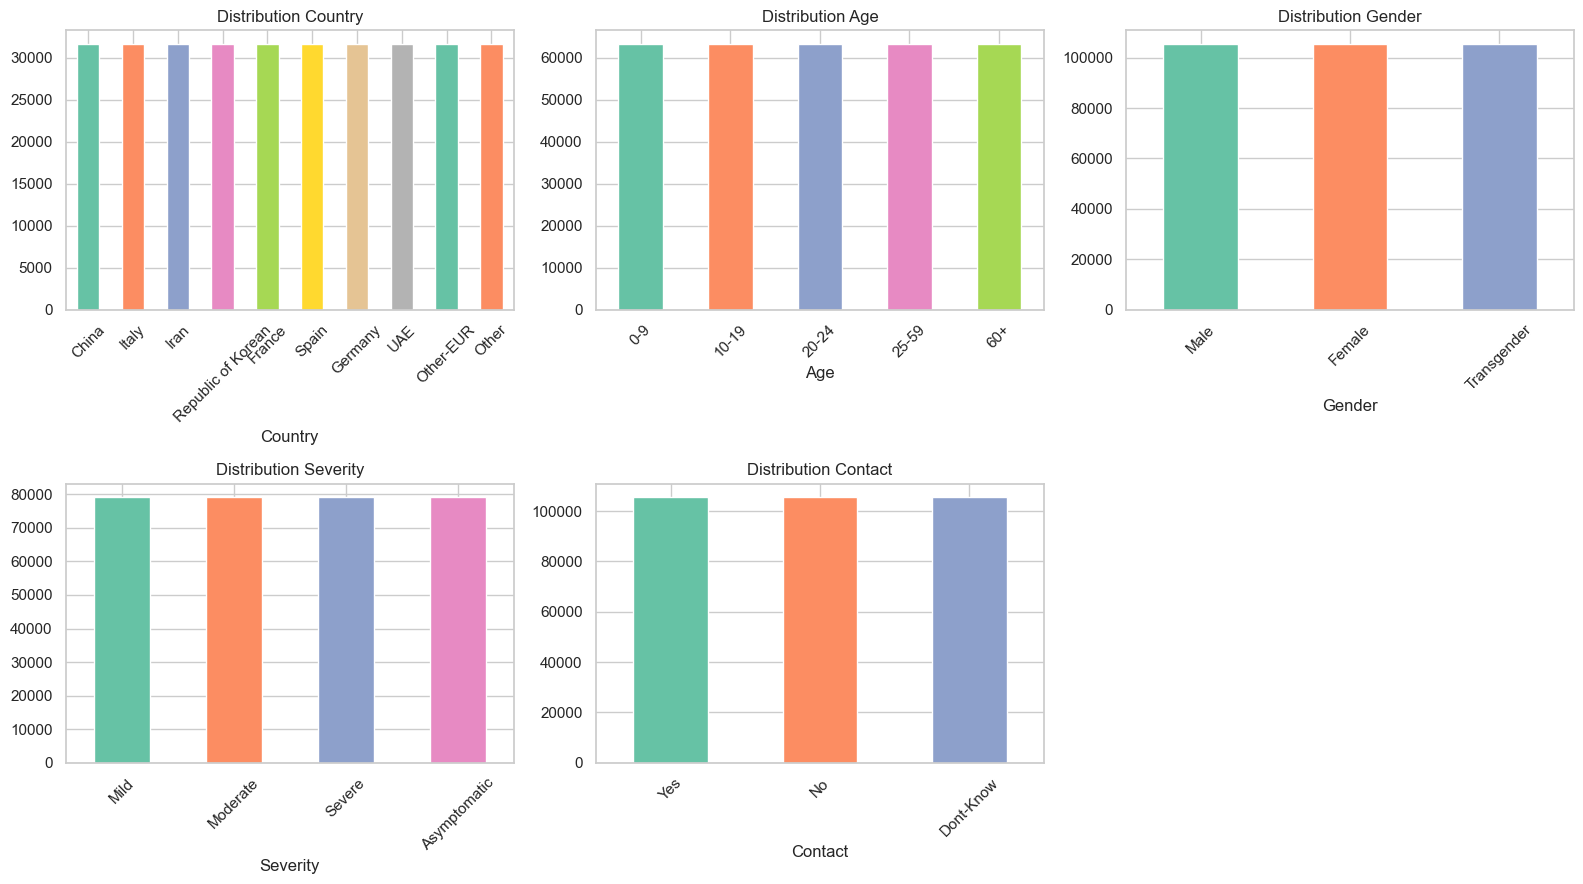

In [11]:
# 3.1 Distributions des variables categorielles simples
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, ['Country', 'Age', 'Gender', 'Severity', 'Contact']):
    df[col].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title(f'Distribution {col}')
    ax.tick_params(axis='x', rotation=45)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


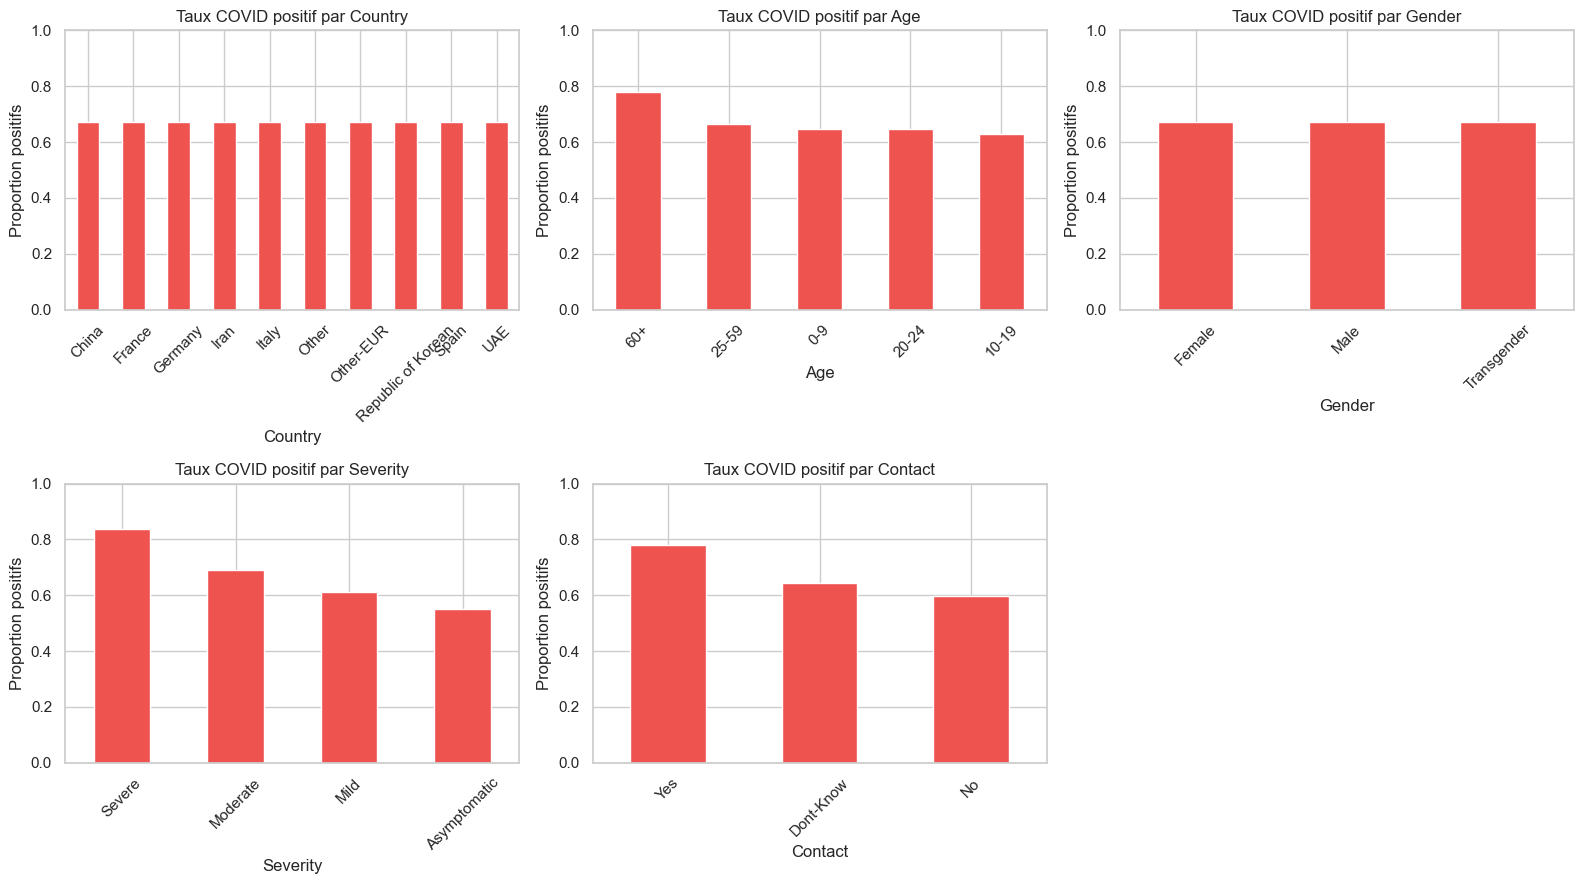

In [12]:
# 3.2 Taux COVID positif par variable
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, ['Country', 'Age', 'Gender', 'Severity', 'Contact']):
    rates = df.groupby(col)['COVID_19'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#ef5350')
    ax.set_title(f'Taux COVID positif par {col}')
    ax.set_ylabel('Proportion positifs')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


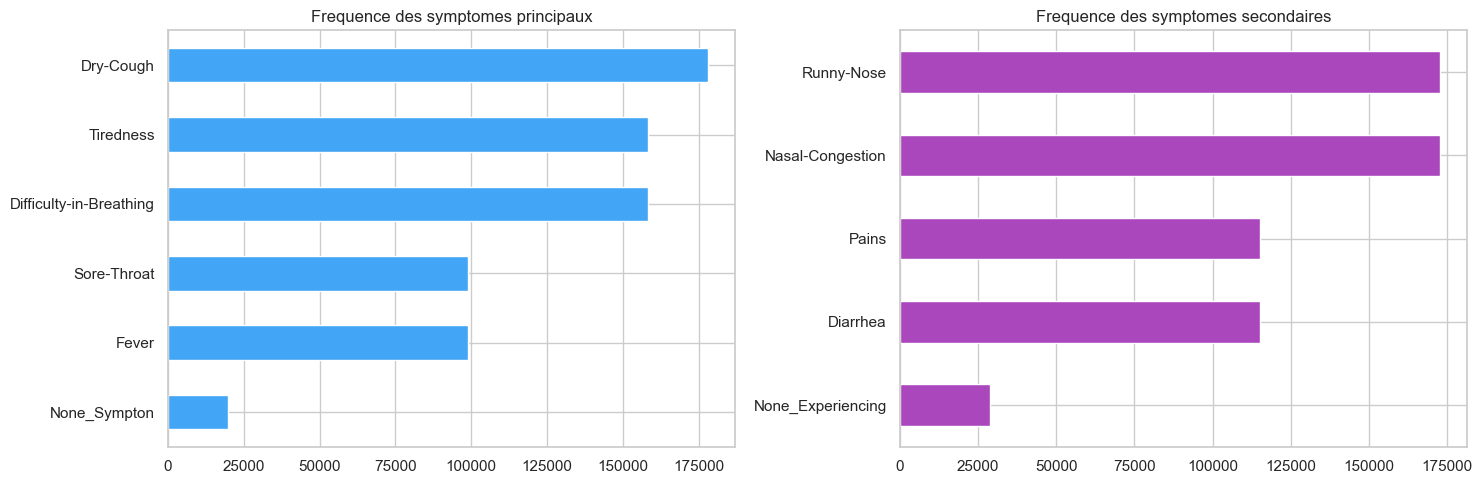

In [13]:
# 3.3 Frequence des tokens de symptomes
sym_freq = {tok: df['Symptoms'].str.contains(tok).sum() for tok in symptom_tokens}
exp_freq = {tok: df['Experiencing_Symptoms'].str.contains(tok).sum() for tok in experiencing_tokens}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
pd.Series(sym_freq).sort_values().plot(kind='barh', ax=ax1, color='#42a5f5')
ax1.set_title('Frequence des symptomes principaux')
pd.Series(exp_freq).sort_values().plot(kind='barh', ax=ax2, color='#ab47bc')
ax2.set_title('Frequence des symptomes secondaires')
plt.tight_layout()
plt.show()


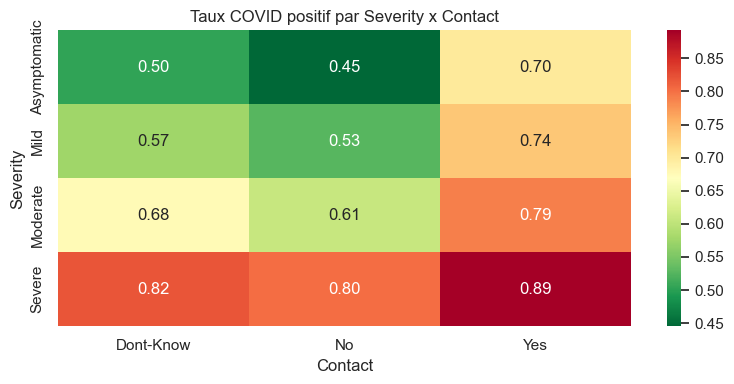

In [14]:
# 3.4 Croisement Severity x Contact vs COVID_19
ct = pd.crosstab([df['Severity']], df['Contact'], values=df['COVID_19'], aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Taux COVID positif par Severity x Contact')
plt.tight_layout()
plt.show()


## Section 4 — Feature Engineering

- **Multi-hot encoding** pour `Symptoms` et `Experiencing_Symptoms` via `MultiLabelBinarizer` (les valeurs sont des listes de tokens séparés par virgule).
- **One-Hot Encoding** (`pd.get_dummies`) pour les variables catégorielles simples.
- **Train/Test split** stratifié 80/20.


In [15]:
# 4.1 Multi-hot encoding
mlb_sym = MultiLabelBinarizer()
mlb_exp = MultiLabelBinarizer()

sym_lists = df['Symptoms'].apply(lambda s: [t.strip() for t in s.split(',')])
exp_lists = df['Experiencing_Symptoms'].apply(lambda s: [t.strip() for t in s.split(',')])

sym_encoded = pd.DataFrame(
    mlb_sym.fit_transform(sym_lists),
    columns=[f'sym_{c}' for c in mlb_sym.classes_],
    index=df.index
)
exp_encoded = pd.DataFrame(
    mlb_exp.fit_transform(exp_lists),
    columns=[f'exp_{c}' for c in mlb_exp.classes_],
    index=df.index
)

print('Symptom features :', sym_encoded.shape)
print('Experiencing features :', exp_encoded.shape)


Symptom features : (316800, 6)
Experiencing features : (316800, 5)


In [16]:
# 4.2 OHE des variables simples
cat_cols = ['Country', 'Age', 'Gender', 'Severity', 'Contact']
df_ohe = pd.get_dummies(df[cat_cols], prefix=cat_cols, drop_first=False)
print('OHE shape :', df_ohe.shape)


OHE shape : (316800, 25)


In [17]:
# 4.3 Matrice de features finale
X = pd.concat([df_ohe, sym_encoded, exp_encoded], axis=1).astype(np.float32)
y = df['COVID_19'].values
feature_names = X.columns.tolist()

print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')
print(f'Nombre de features : {len(feature_names)}')


X shape  : (316800, 36)
y shape  : (316800,)
Nombre de features : 36


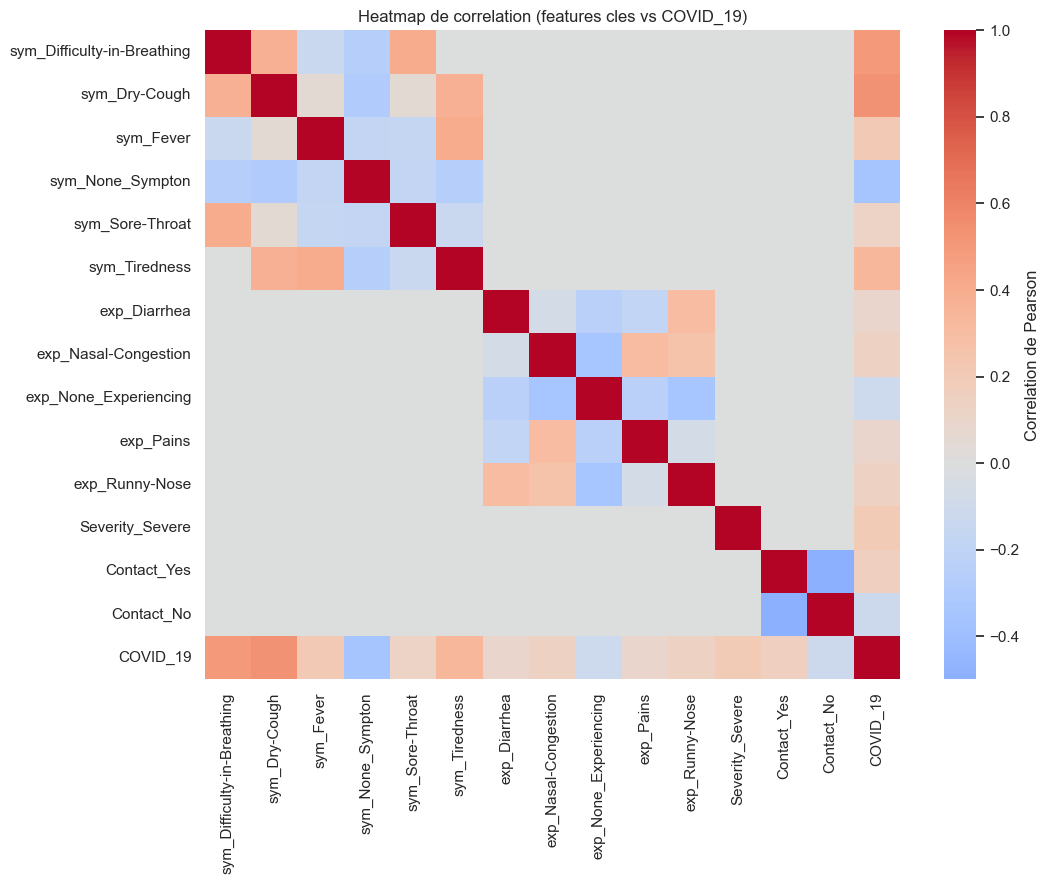

In [18]:
# 4.4 Heatmap de correlation (echantillon de features pour lisibilite)
sample_cols = (sym_encoded.columns.tolist() + exp_encoded.columns.tolist()
               + ['Severity_Severe', 'Severity_None', 'Contact_Yes', 'Contact_No'])
sample_cols = [c for c in sample_cols if c in X.columns]
corr = pd.concat([X[sample_cols], df['COVID_19'].rename('COVID_19')], axis=1).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Correlation de Pearson'})
ax.set_title('Heatmap de correlation (features cles vs COVID_19)')
plt.tight_layout()
plt.show()


In [19]:
# 4.5 Split stratifie
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train : {X_train.shape}, positifs : {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}, positifs : {y_test.mean():.3f}')


Train : (253440, 36), positifs : 0.673
Test  : (63360, 36), positifs : 0.673


## Section 5 — Modèles de classification supervisée

Cinq modèles sont entraînés via `sklearn.Pipeline` et comparés sur :
- **Accuracy**, **Precision**, **Recall**, **F1-score**, **AUC-ROC**
- **Matrice de confusion** et **courbe ROC**

> **Note SVM** : sur 316k lignes, `SVC(kernel='rbf')` est prohibitif en mémoire/temps. On utilise `LinearSVC` enveloppé dans `CalibratedClassifierCV` pour obtenir des probabilités calibrées.


In [20]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                                   class_weight='balanced', n_jobs=-1))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=15,
                                       class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'SVM (Linear, calibrated)': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight='balanced',
                      max_iter=2000, random_state=RANDOM_STATE),
            cv=3, n_jobs=-1
        ))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                            max_depth=5, random_state=RANDOM_STATE))
    ]),
}
print(f'{len(models)} modeles a entrainer.')


5 modeles a entrainer.


In [21]:
# Boucle d'entrainement et evaluation
results = {}
fitted = {}

for name, pipe in models.items():
    print(f'\n[Training] {name}...')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        y_prob = None
        auc = np.nan
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'AUC-ROC':   auc,
    }
    fitted[name] = pipe
    print(f'  -> Accuracy = {results[name]["Accuracy"]:.4f} | F1 = {results[name]["F1"]:.4f}')

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
results_df.style.format('{:.4f}').background_gradient(cmap='Greens', subset=['F1', 'AUC-ROC'])



[Training] Logistic Regression...


  -> Accuracy = 0.9840 | F1 = 0.9880

[Training] Random Forest...


  -> Accuracy = 0.9963 | F1 = 0.9972

[Training] SVM (Linear, calibrated)...


  -> Accuracy = 0.9857 | F1 = 0.9894

[Training] KNN...


  File "C:\Users\Lucas Madjinda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lucas Madjinda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", l

  -> Accuracy = 0.8704 | F1 = 0.9082

[Training] Gradient Boosting...


  -> Accuracy = 0.9998 | F1 = 0.9999


,Accuracy,Precision,Recall,F1,AUC-ROC
Gradient Boosting,0.9998,0.9998,1.0000,0.9999,1.0000
Random Forest,0.9963,1.0000,0.9945,0.9972,1.0000
"SVM (Linear, calibrated)",0.9857,0.9886,0.9902,0.9894,0.9992
Logistic Regression,0.9840,0.9943,0.9819,0.9880,0.9992
KNN,0.8704,0.8676,0.9529,0.9082,0.9381


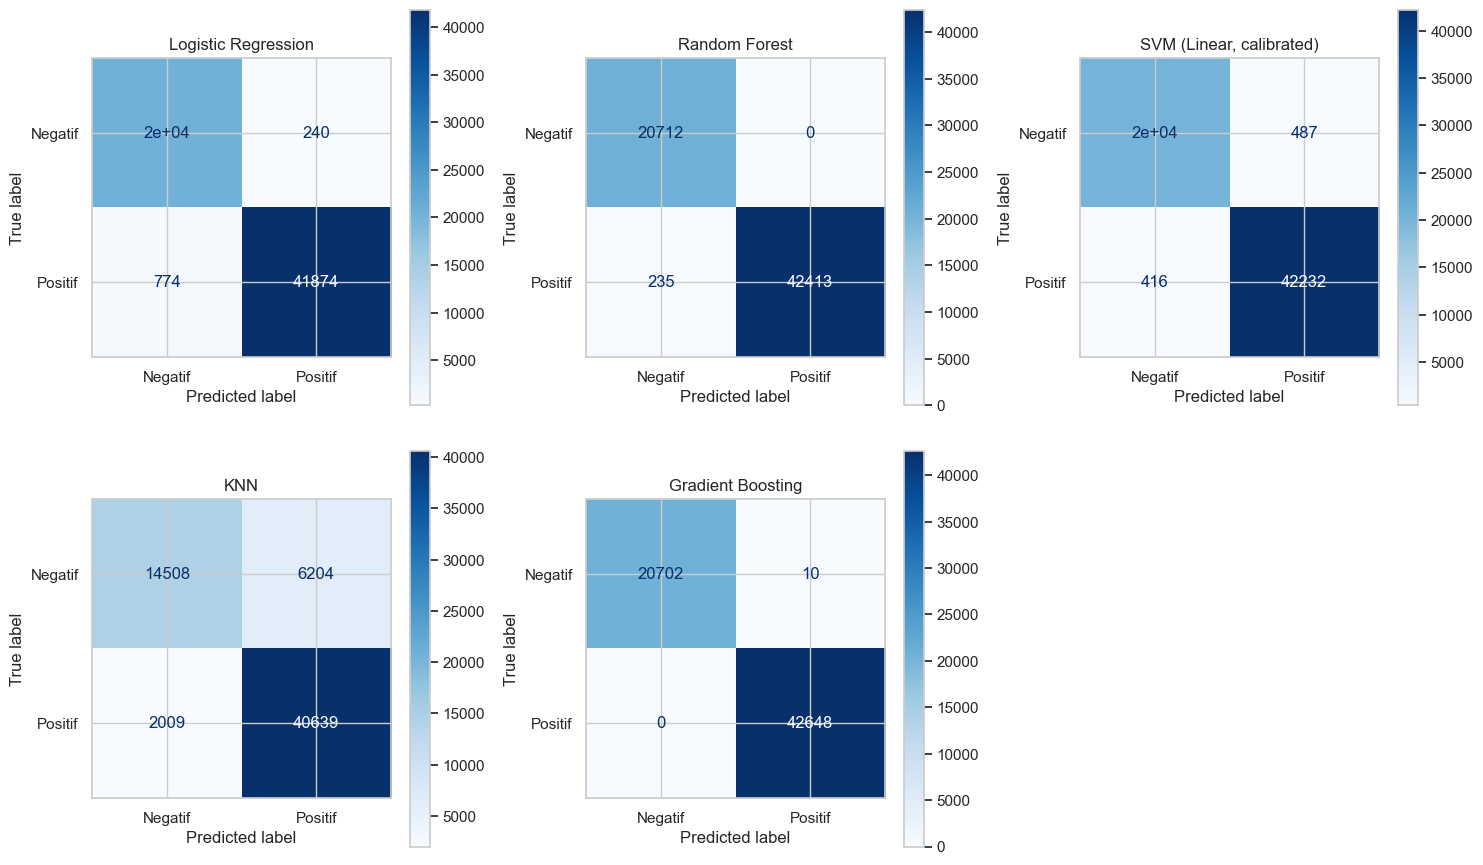

In [22]:
# Matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, pipe) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test, ax=ax, cmap='Blues',
        display_labels=['Negatif', 'Positif']
    )
    ax.set_title(name)
for ax in axes[len(fitted):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


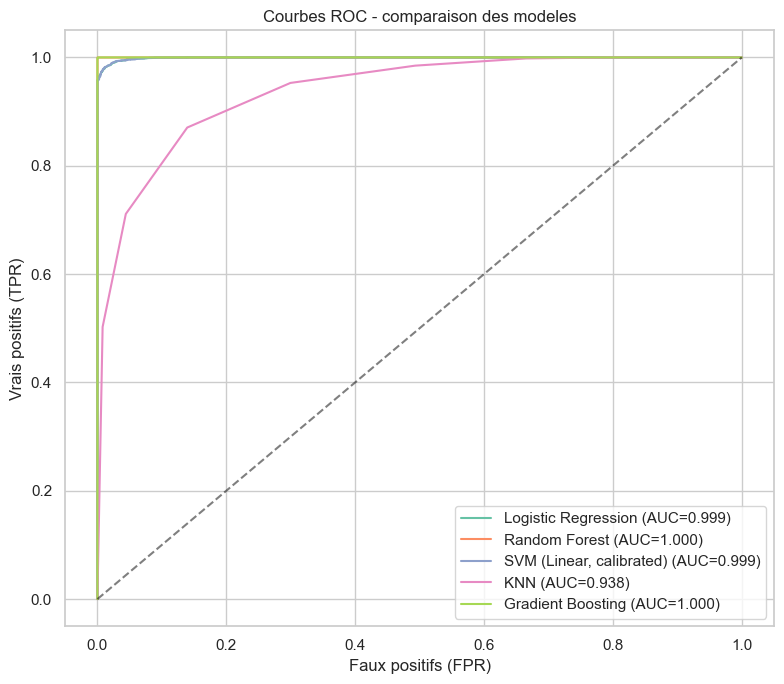

In [23]:
# Courbes ROC superposees
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in fitted.items():
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        ax.plot(fpr, tpr, label=f'{name} (AUC={results[name]["AUC-ROC"]:.3f})')
    except Exception:
        continue
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Faux positifs (FPR)')
ax.set_ylabel('Vrais positifs (TPR)')
ax.set_title('Courbes ROC - comparaison des modeles')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


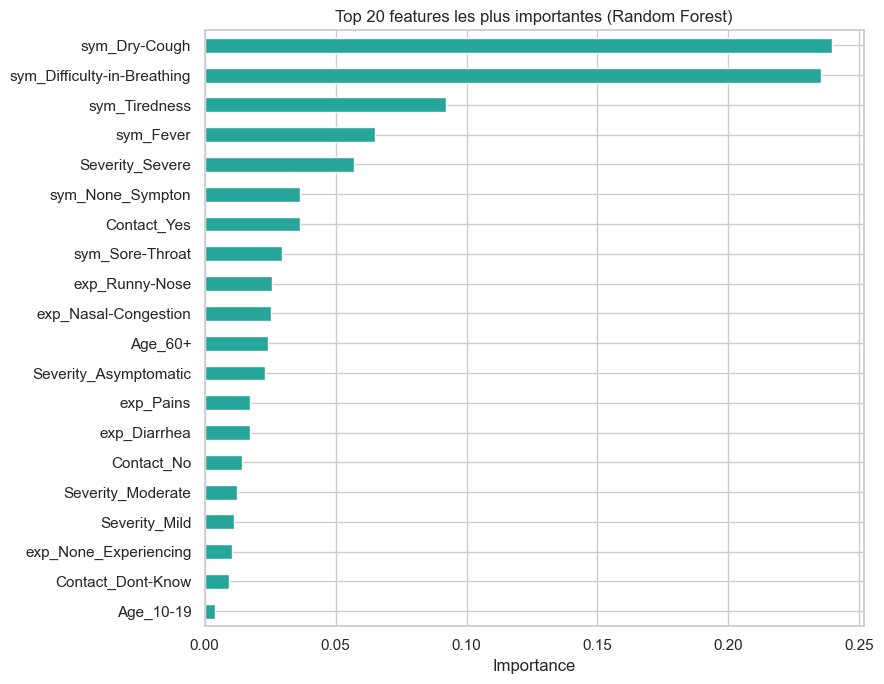

In [24]:
# Importance des features (Random Forest)
rf = fitted['Random Forest'].named_steps['clf']
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
imp.iloc[::-1].plot(kind='barh', ax=ax, color='#26a69a')
ax.set_title('Top 20 features les plus importantes (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


In [25]:
# Selection du meilleur modele
best_name = results_df.index[0]
best_model = fitted[best_name]
print(f'>>> Meilleur modele : {best_name} (F1 = {results_df.loc[best_name, "F1"]:.4f})')
print('\nRapport detaille :')
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=['Negatif', 'Positif']))


>>> Meilleur modele : Gradient Boosting (F1 = 0.9999)

Rapport detaille :


              precision    recall  f1-score   support

     Negatif       1.00      1.00      1.00     20712
     Positif       1.00      1.00      1.00     42648

    accuracy                           1.00     63360
   macro avg       1.00      1.00      1.00     63360
weighted avg       1.00      1.00      1.00     63360



## Section 6 — Chatbot interactif (interrogatoire médical)

L'utilisateur (le médecin) répond séquentiellement à 7 questions. Les réponses sont encodées **exactement** comme à l'entraînement (alignement strict des colonnes de features), puis passées au meilleur modèle pour obtenir une prédiction avec niveau de confiance.

Deux versions sont fournies :
1. **Version `ipywidgets`** — interface interactive dans Jupyter
2. **Version `input()`** — fallback fonctionnant en console / nbconvert


In [26]:
class ChatbotState:
    """Etat du chatbot : collecte les reponses et encode pour la prediction."""

    def __init__(self, model, mlb_sym, mlb_exp, feature_names):
        self.model = model
        self.mlb_sym = mlb_sym
        self.mlb_exp = mlb_exp
        self.feature_names = feature_names
        self.answers = {}

    def encode(self):
        temp = pd.DataFrame([{
            'Country':  self.answers['Country'],
            'Age':      self.answers['Age'],
            'Gender':   self.answers['Gender'],
            'Severity': self.answers['Severity'],
            'Contact':  self.answers['Contact'],
        }])
        ohe = pd.get_dummies(temp, prefix=temp.columns.tolist())

        sym_vec = self.mlb_sym.transform([self.answers['Symptoms']])
        exp_vec = self.mlb_exp.transform([self.answers['Experiencing_Symptoms']])
        sym_df = pd.DataFrame(sym_vec, columns=[f'sym_{c}' for c in self.mlb_sym.classes_])
        exp_df = pd.DataFrame(exp_vec, columns=[f'exp_{c}' for c in self.mlb_exp.classes_])

        row = pd.concat([ohe.reset_index(drop=True),
                         sym_df.reset_index(drop=True),
                         exp_df.reset_index(drop=True)], axis=1)
        row = row.reindex(columns=self.feature_names, fill_value=0).astype(np.float32)
        return row

    def predict(self):
        X_in = self.encode()
        label = int(self.model.predict(X_in)[0])
        proba = self.model.predict_proba(X_in)[0]
        return label, proba


# Definitions des questions
QUESTIONS = [
    {'key': 'Country',  'label': 'Pays visite recemment ?',
     'options': vocab['Country'], 'type': 'single'},
    {'key': 'Age',      'label': "Groupe d'age ?",
     'options': vocab['Age'], 'type': 'single'},
    {'key': 'Gender',   'label': 'Genre ?',
     'options': vocab['Gender'], 'type': 'single'},
    {'key': 'Symptoms', 'label': 'Symptomes principaux (selection multiple) :',
     'options': list(mlb_sym.classes_), 'type': 'multi'},
    {'key': 'Experiencing_Symptoms', 'label': 'Autres symptomes (selection multiple) :',
     'options': list(mlb_exp.classes_), 'type': 'multi'},
    {'key': 'Severity', 'label': 'Gravite percue ?',
     'options': vocab['Severity'], 'type': 'single'},
    {'key': 'Contact',  'label': 'Contact avec patient COVID ?',
     'options': vocab['Contact'], 'type': 'single'},
]

print(f'{len(QUESTIONS)} questions definies.')


7 questions definies.


In [27]:
# Version ipywidgets (Jupyter)
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

    def run_chatbot_widgets():
        state = ChatbotState(best_model, mlb_sym, mlb_exp, feature_names)
        out = widgets.Output()
        step = [0]

        def show_step(i):
            with out:
                clear_output()
                q = QUESTIONS[i]
                display(HTML(f"<h3>Question {i+1}/{len(QUESTIONS)} - {q['label']}</h3>"))

                if q['type'] == 'single':
                    w = widgets.RadioButtons(options=q['options'], description='', layout=widgets.Layout(width='auto'))
                else:
                    w = widgets.SelectMultiple(options=q['options'], rows=min(8, len(q['options'])),
                                               description='', layout=widgets.Layout(width='auto'))

                btn = widgets.Button(description='Suivant' if i < len(QUESTIONS) - 1 else 'Predire',
                                     button_style='primary')

                def on_click(_):
                    val = w.value
                    if q['type'] == 'multi':
                        state.answers[q['key']] = list(val) if val else []
                    else:
                        state.answers[q['key']] = val
                    if step[0] < len(QUESTIONS) - 1:
                        step[0] += 1
                        show_step(step[0])
                    else:
                        show_result()

                btn.on_click(on_click)
                display(w, btn)

        def show_result():
            with out:
                clear_output()
                label, proba = state.predict()
                tag = 'POSITIF' if label == 1 else 'NEGATIF'
                color = '#d32f2f' if label == 1 else '#388e3c'
                conf = proba[label] * 100
                display(HTML(f"""
                    <div style="padding:24px; border-radius:12px;
                                background:{color}1A; border:2px solid {color};
                                font-family:Arial, sans-serif;">
                        <h2 style="color:{color}; margin:0;">Diagnostic : COVID-19 {tag}</h2>
                        <p style="font-size:18px; margin:12px 0;">
                            Confiance du modele : <strong>{conf:.1f}%</strong>
                        </p>
                        <p>Probabilite positive : {proba[1]*100:.1f}% &nbsp;|&nbsp;
                           Probabilite negative : {proba[0]*100:.1f}%</p>
                        <hr>
                        <p><strong>Reponses collectees :</strong></p>
                        <pre style="font-size:12px;">{state.answers}</pre>
                        <small style="color:#666;">Modele : {best_name}.
                        Ce resultat ne constitue pas un avis medical.</small>
                    </div>
                """))

        show_step(0)
        display(out)

    run_chatbot_widgets()
except ImportError:
    print('ipywidgets non disponible - utilisez la version console ci-dessous.')


Output()

In [28]:
# Version console (fallback) - executer cette cellule en remplacement si widgets KO
def run_chatbot_console():
    state = ChatbotState(best_model, mlb_sym, mlb_exp, feature_names)
    print('=== Chatbot COVID-19 (mode console) ===\n')
    for q in QUESTIONS:
        print(f"Q : {q['label']}")
        for i, opt in enumerate(q['options']):
            print(f'  [{i}] {opt}')
        if q['type'] == 'single':
            raw_in = input('Choix (numero) : ').strip()
            idx = int(raw_in) if raw_in.isdigit() else 0
            state.answers[q['key']] = q['options'][idx]
        else:
            raw_in = input('Choix (numeros separes par virgule, vide = aucun) : ').strip()
            if raw_in:
                idxs = [int(x.strip()) for x in raw_in.split(',') if x.strip().isdigit()]
                state.answers[q['key']] = [q['options'][i] for i in idxs]
            else:
                state.answers[q['key']] = []
        print()

    label, proba = state.predict()
    tag = 'POSITIF' if label == 1 else 'NEGATIF'
    print(f'\n=== Diagnostic : COVID-19 {tag} ===')
    print(f'Confiance : {proba[label]*100:.1f}%')
    print(f'Probabilites - Negatif : {proba[0]*100:.1f}% | Positif : {proba[1]*100:.1f}%')

# run_chatbot_console()  # decommenter pour utiliser
print('Version console definie - decommentez run_chatbot_console() pour la lancer.')


Version console definie - decommentez run_chatbot_console() pour la lancer.


In [29]:
# Demonstration non-interactive : prediction sur un cas test fictif
demo_state = ChatbotState(best_model, mlb_sym, mlb_exp, feature_names)
demo_state.answers = {
    'Country': 'France',
    'Age': '60+',
    'Gender': 'Male',
    'Symptoms': ['Fever', 'Dry-Cough', 'Difficulty-in-Breathing'],
    'Experiencing_Symptoms': ['Pains', 'Diarrhea'],
    'Severity': 'Severe',
    'Contact': 'Yes',
}
label, proba = demo_state.predict()
print(f"Cas test (patient age 60+, contact Yes, symptomes severes) :")
print(f'  Diagnostic : {"POSITIF" if label == 1 else "NEGATIF"}')
print(f'  Confiance  : {proba[label]*100:.1f}%')
print(f'  Probabilites : neg={proba[0]*100:.1f}%, pos={proba[1]*100:.1f}%')


Cas test (patient age 60+, contact Yes, symptomes severes) :
  Diagnostic : POSITIF
  Confiance  : 100.0%
  Probabilites : neg=0.0%, pos=100.0%


## Section 7 — Clustering non supervisé

Segmentation des patients en clusters homogènes sans utiliser le label `COVID_19`.

- **PCA** pour réduire la dimensionnalité (95% de variance retenue)
- **KMeans** avec choix de k via la méthode du coude + silhouette
- **DBSCAN** sur un sous-échantillon
- Profiling des clusters obtenus


In [30]:
# Sous-echantillonnage pour des temps de calcul raisonnables
sample_idx = np.random.choice(len(X), size=20_000, replace=False)
X_sample = X.iloc[sample_idx].values

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)
print(f'PCA : {X_sample.shape[1]} -> {X_pca.shape[1]} composantes ({pca.explained_variance_ratio_.sum():.3f} variance)')


PCA : 36 -> 27 composantes (0.951 variance)


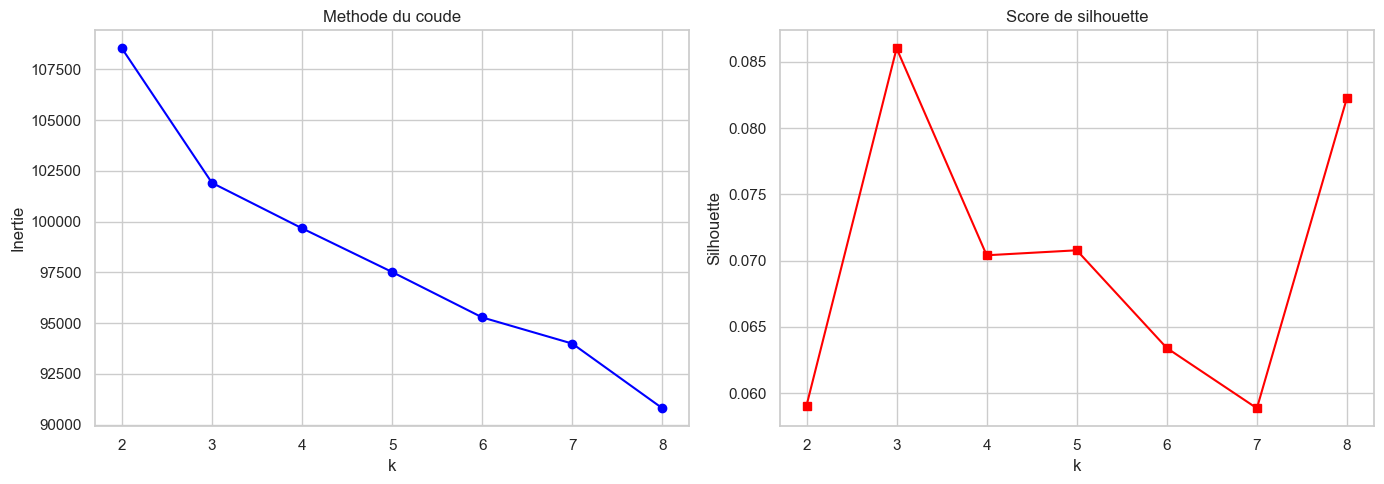

Meilleur k (silhouette) : 3 (score = 0.086)


In [31]:
# Methode du coude + silhouette
K_RANGE = range(2, 9)
inertias, sils = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, labels, sample_size=3000, random_state=RANDOM_STATE))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_RANGE), inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertie'); ax1.set_title('Methode du coude')
ax2.plot(list(K_RANGE), sils, 'rs-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette'); ax2.set_title('Score de silhouette')
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[int(np.argmax(sils))]
print(f'Meilleur k (silhouette) : {best_k} (score = {max(sils):.3f})')


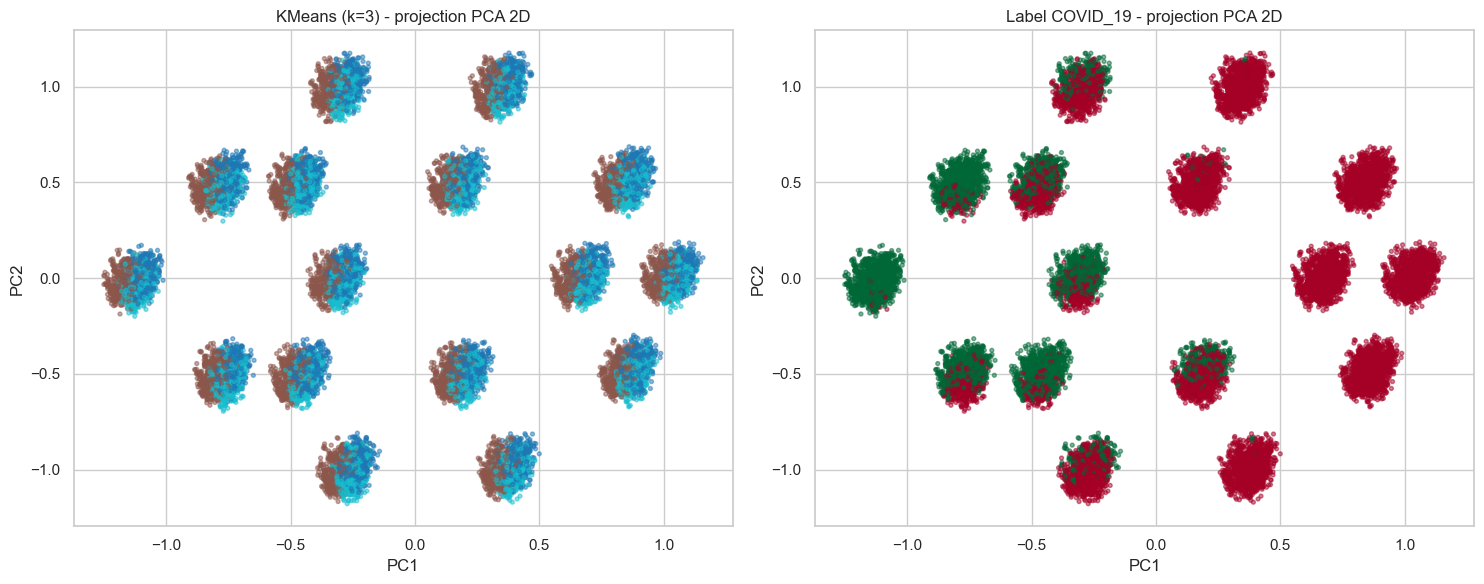

In [32]:
# KMeans final
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters = km_final.fit_predict(X_pca)

# Visualisation PCA 2D
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='tab10', alpha=0.5, s=8)
ax1.set_title(f'KMeans (k={best_k}) - projection PCA 2D')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=df.iloc[sample_idx]['COVID_19'].values,
            cmap='RdYlGn_r', alpha=0.5, s=8)
ax2.set_title('Label COVID_19 - projection PCA 2D')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
plt.tight_layout()
plt.show()


In [33]:
# Profiling des clusters
profile_df = df.iloc[sample_idx].copy()
profile_df['Cluster'] = clusters

profile = profile_df.groupby('Cluster').agg(
    n_patients=('COVID_19', 'size'),
    taux_covid=('COVID_19', 'mean'),
    severity_mode=('Severity', lambda x: x.mode().iloc[0]),
    age_mode=('Age', lambda x: x.mode().iloc[0]),
    contact_mode=('Contact', lambda x: x.mode().iloc[0]),
)
print('Profiling des clusters KMeans :')
profile


Profiling des clusters KMeans :


,n_patients,taux_covid,severity_mode,age_mode,contact_mode
Cluster,,,,,
0,6752,0.640847,Asymptomatic,0-9,Dont-Know
1,6673,0.587892,Moderate,60+,No
2,6575,0.778707,Moderate,20-24,Yes


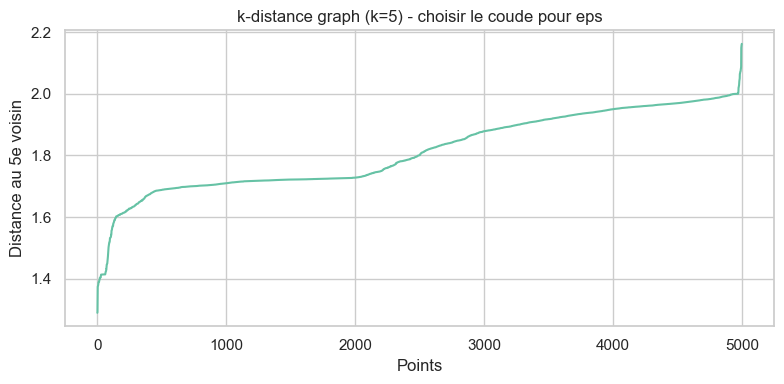

eps estime : 1.970


DBSCAN : 1 clusters, 22 points de bruit


In [34]:
# DBSCAN sur sous-echantillon plus petit
from sklearn.neighbors import NearestNeighbors

small_idx = np.random.choice(len(X_pca), size=5000, replace=False)
X_small = X_pca[small_idx]

# Selection eps via k-distance graph
nn = NearestNeighbors(n_neighbors=5).fit(X_small)
dist, _ = nn.kneighbors(X_small)
dist_sorted = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dist_sorted)
ax.set_title('k-distance graph (k=5) - choisir le coude pour eps')
ax.set_xlabel('Points'); ax.set_ylabel('Distance au 5e voisin')
plt.tight_layout()
plt.show()

# DBSCAN avec eps estime
eps_value = float(np.percentile(dist_sorted, 90))
print(f'eps estime : {eps_value:.3f}')
db = DBSCAN(eps=eps_value, min_samples=5).fit(X_small)
n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f'DBSCAN : {n_clusters_db} clusters, {n_noise} points de bruit')


---

## Conclusion

Ce projet implémente un **chatbot médical** pour le pré-diagnostic du COVID-19 :

1. Génération d'un dataset complet de 316 800 cas synthétiques à partir d'un vocabulaire de labels
2. Pipeline d'encodage robuste (multi-hot pour symptômes, OHE pour catégorielles simples)
3. Comparaison de 5 modèles de classification avec sélection du meilleur sur F1
4. Interface interactive (ipywidgets) avec encodage strictement aligné sur l'entraînement
5. Analyse non supervisée par clustering pour identifier des profils homogènes

**Limites** : le label COVID_19 est issu d'une règle heuristique et non d'une ground truth clinique réelle. Les résultats sont à interpréter comme une démonstration méthodologique.
